# 🔭 Clase 4 — Análisis Exploratorio de Datos (EDA) + Hito 1

**Curso:** Introducción a la Ciencia de Datos  
**Sesión:** 4 de 8  
**Herramientas:** pandas · matplotlib · seaborn · (plotly opcional)

---

## Objetivos de esta clase

Al terminar esta sesión vas a poder:

1. Calcular e interpretar estadísticas descriptivas aplicadas a un problema real
2. Elegir la visualización correcta según el tipo de pregunta y de variable
3. Construir un notebook de EDA completo y ordenado sobre tu dataset propio
4. Comunicar hallazgos exploratorios con una narrativa clara de 5 minutos

---

> 🗺️ **Estructura de esta clase:**
> - **Secciones 1–5:** Tutorial completo de EDA con un dataset de ejemplo
> - **Sección 6:** Guía para construir tu propio EDA
> - **Sección 7:** Hito 1 — presentación grupal y retroalimentación

## ⚙️ Sección 0 — Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# Plotly es opcional — para gráficos interactivos
try:
    import plotly.express as px
    import plotly.graph_objects as go
    PLOTLY = True
    print('Plotly disponible ✅')
except ImportError:
    PLOTLY = False
    print('Plotly no disponible — continuaremos con matplotlib/seaborn')

# Configuración global de estilo
plt.rcParams.update({
    'figure.figsize':    (12, 5),
    'font.size':         12,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.spines.top':   False,
    'axes.spines.right': False,
})
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)

# Paleta de colores consistente para todo el notebook
PAL_MAIN  = '#2c7bb6'
PAL_ACC   = '#d7191c'
PAL_NEUT  = '#636363'
PAL_CAT   = sns.color_palette('Set2', 8)

print('✅ Setup completo.')

Plotly disponible ✅
✅ Setup completo.


## 🏗️ Dataset de trabajo

Usaremos el dataset de **bienestar estudiantil universitario** — una encuesta simulada con variables demográficas, académicas y de salud mental. Tiene la variedad suficiente para demostrar todas las técnicas de EDA.

**Pregunta de investigación de ejemplo:**  
*¿Qué factores académicos, socioeconómicos y de hábitos se asocian con el nivel de estrés reportado por los estudiantes?*

In [2]:
np.random.seed(42)
n = 400

carreras    = ['Ingeniería', 'Medicina', 'Derecho', 'Pedagogía', 'Arte', 'Psicología']
anos        = [1, 2, 3, 4, 5]
residencias = ['Con familia', 'Residencia universitaria', 'Arriendo compartido', 'Solo/a']
ingresos    = ['< $400k', '$400k–$800k', '$800k–$1.5M', '> $1.5M']

carrera_col  = np.random.choice(carreras, n, p=[0.30, 0.15, 0.15, 0.20, 0.10, 0.10])
ano_col      = np.random.choice(anos, n, p=[0.28, 0.24, 0.22, 0.16, 0.10])

# El estrés depende de carrera y año (variable objetivo)
estres_base = {
    'Ingeniería': 7.0, 'Medicina': 7.8, 'Derecho': 6.8,
    'Pedagogía': 5.5, 'Arte': 4.8, 'Psicología': 5.9
}
estres_ano = {1: -0.5, 2: 0.0, 3: 0.5, 4: 0.8, 5: 1.2}

estres_raw = np.array([
    estres_base[c] + estres_ano[a] + np.random.normal(0, 1.2)
    for c, a in zip(carrera_col, ano_col)
]).clip(1, 10).round(1)

# Promedio académico: inversamente relacionado con estrés extremo
promedio = (7.5 - 0.15 * estres_raw + np.random.normal(0, 0.6, n)).clip(4.0, 7.0).round(1)

# Horas de sueño: menos sueño → más estrés
horas_sueno = (9.0 - 0.4 * estres_raw + np.random.normal(0, 0.8, n)).clip(4, 12).round(1)

# Actividad física (días/semana)
actividad = np.random.choice([0,1,2,3,4,5,6,7], n, p=[0.10,0.15,0.20,0.25,0.15,0.10,0.03,0.02])

df = pd.DataFrame({
    'carrera':      carrera_col,
    'ano':          ano_col,
    'residencia':   np.random.choice(residencias, n, p=[0.35, 0.20, 0.35, 0.10]),
    'ingreso_fam':  np.random.choice(ingresos, n, p=[0.25, 0.35, 0.25, 0.15]),
    'promedio':     promedio,
    'horas_estudio': (estres_raw * 1.8 + np.random.normal(0, 2, n)).clip(1, 20).round(1),
    'horas_sueno':  horas_sueno,
    'actividad_fis': actividad,
    'usa_redes':    np.random.choice([0,1], n, p=[0.30, 0.70]),
    'trabaja':      np.random.choice([0,1], n, p=[0.65, 0.35]),
    'nivel_estres': estres_raw,
})

# Variable derivada: categoría de estrés
df['cat_estres'] = pd.cut(
    df['nivel_estres'],
    bins=[0, 4, 6, 8, 10],
    labels=['Bajo (1–4)', 'Moderado (4–6)', 'Alto (6–8)', 'Severo (8–10)']
)

print(f'Dataset: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head()

Dataset: 400 filas × 12 columnas


,carrera,ano,residencia,ingreso_fam,promedio,horas_estudio,horas_sueno,actividad_fis,usa_redes,trabaja,nivel_estres,cat_estres
0,Medicina,1,Residencia universitaria,$400k–$800k,6.90,12.70,6.90,4,1,1,6.40,Alto (6–8)
1,Psicología,5,Con familia,> $1.5M,6.00,12.70,6.80,0,0,1,7.70,Alto (6–8)
2,Pedagogía,2,Con familia,$400k–$800k,6.30,13.20,5.60,0,1,0,7.80,Alto (6–8)
3,Derecho,4,Con familia,$400k–$800k,7.00,14.70,4.60,2,1,0,9.20,Severo (8–10)
4,Ingeniería,2,Arriendo compartido,$400k–$800k,7.00,16.00,4.60,5,1,0,8.90,Severo (8–10)


---

## 📖 Sección 1 — ¿Qué es el EDA y para qué sirve?

El **Análisis Exploratorio de Datos** (EDA) fue formalizado por John Tukey en 1977. Su idea central: antes de modelar, hay que *escuchar* a los datos.

```
FLUJO DE UN EDA
───────────────────────────────────────────────────────────────────
  1. ¿Cómo se distribuye cada variable?      → histogramas, boxplots
  2. ¿Cómo se relacionan las variables?      → scatter, correlaciones
  3. ¿Hay diferencias entre grupos?          → barplots, violinplots
  4. ¿Hay anomalías, patrones o tendencias?  → todo lo anterior
  5. ¿Responde el dataset la pregunta?       → conclusión exploratoria
───────────────────────────────────────────────────────────────────
```

### Dos errores frecuentes en EDA

| ❌ Error | ✅ Corrección |
|---|---|
| Hacer gráficos sin pregunta detrás | Cada gráfico debe responder una pregunta específica |
| Confundir correlación con causalidad | Dos variables pueden moverse juntas sin que una cause la otra |
| Reportar solo lo que confirma tu hipótesis | El EDA debe buscar activamente lo que *sorprende* |
| Hacer 30 gráficos y no concluir nada | Un EDA termina con hallazgos escritos, no solo con figuras |

---

## 📊 Sección 2 — Estadística Descriptiva Aplicada

Las estadísticas descriptivas son el primer resumen cuantitativo de tus datos. No reemplazan a los gráficos, pero los complementan.

```
MEDIDAS DE TENDENCIA CENTRAL        MEDIDAS DE DISPERSIÓN
────────────────────────────        ──────────────────────────────
Media    → promedio aritmético      Rango      → max - min
Mediana  → valor del medio          Varianza   → promedio de (x-μ)²
Moda     → valor más frecuente      Std Dev    → √varianza
                                    IQR        → Q3 - Q1
                                    CV         → std / media × 100

Cuándo usar mediana vs media:
  Distribución simétrica → media ≈ mediana → cualquiera sirve
  Distribución sesgada   → mediana es más robusta
  Hay outliers           → mediana es más robusta
```

In [3]:
# .describe() extendido: agrega percentiles intermedios
cols_num = ['promedio', 'horas_estudio', 'horas_sueno', 'actividad_fis', 'nivel_estres']

desc = df[cols_num].describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90])
print('=== Estadísticas descriptivas ===')
desc

=== Estadísticas descriptivas ===


,promedio,horas_estudio,horas_sueno,actividad_fis,nivel_estres
count,400.00,400.00,400.00,400.00,400.00
mean,6.44,11.98,6.36,2.71,6.74
std,0.53,3.50,0.99,1.67,1.57
min,4.60,2.50,4.00,0.00,3.10
10%,5.60,7.19,5.10,0.00,4.69
25%,6.10,9.57,5.70,2.00,5.60
50%,6.50,12.30,6.40,3.00,6.80
75%,6.90,14.50,7.00,4.00,7.80
90%,7.00,16.30,7.60,5.00,8.90
max,7.00,20.00,9.40,7.00,10.00


In [4]:
# Tabla extendida: agrega sesgo, curtosis y CV
tabla_desc = pd.DataFrame({
    'Media':    df[cols_num].mean(),
    'Mediana':  df[cols_num].median(),
    'Std':      df[cols_num].std(),
    'CV (%)':   (df[cols_num].std() / df[cols_num].mean() * 100).round(1),
    'Sesgo':    df[cols_num].skew().round(2),
    'Curtosis': df[cols_num].kurt().round(2),
    'Min':      df[cols_num].min(),
    'Max':      df[cols_num].max(),
}).round(2)

print('=== Tabla descriptiva completa ===')
print(tabla_desc.to_string())
print()
print('Interpretación del sesgo:')
print('  > 0: cola larga hacia la derecha (valores altos inusuales)')
print('  < 0: cola larga hacia la izquierda (valores bajos inusuales)')
print('  ≈ 0: distribución aproximadamente simétrica')

=== Tabla descriptiva completa ===
               Media  Mediana  Std  CV (%)  Sesgo  Curtosis  Min   Max
promedio        6.44     6.50 0.53    8.20  -0.82      0.02 4.60  7.00
horas_estudio  11.98    12.30 3.50   29.20  -0.26     -0.33 2.50 20.00
horas_sueno     6.36     6.40 0.99   15.60   0.10      0.04 4.00  9.40
actividad_fis   2.71     3.00 1.67   61.80   0.28     -0.30 0.00  7.00
nivel_estres    6.74     6.80 1.57   23.40  -0.04     -0.63 3.10 10.00

Interpretación del sesgo:
  > 0: cola larga hacia la derecha (valores altos inusuales)
  < 0: cola larga hacia la izquierda (valores bajos inusuales)
  ≈ 0: distribución aproximadamente simétrica


In [5]:
# Resumen de variables categóricas
cols_cat = ['carrera', 'ano', 'residencia', 'ingreso_fam', 'cat_estres']

print('=== Variables categóricas — frecuencias ===')
for col in cols_cat:
    conteo = df[col].value_counts()
    pct    = (conteo / len(df) * 100).round(1)
    tabla  = pd.DataFrame({'N': conteo, '%': pct})
    print(f'\n{col}:')
    print(tabla.to_string())

=== Variables categóricas — frecuencias ===

carrera:
              N     %
carrera              
Ingeniería  125 31.20
Pedagogía    84 21.00
Medicina     56 14.00
Derecho      54 13.50
Arte         43 10.80
Psicología   38  9.50

ano:
       N     %
ano           
1    116 29.00
2     90 22.50
3     83 20.80
4     66 16.50
5     45 11.20

residencia:
                            N     %
residencia                         
Con familia               142 35.50
Arriendo compartido       141 35.20
Residencia universitaria   71 17.80
Solo/a                     46 11.50

ingreso_fam:
               N     %
ingreso_fam           
$400k–$800k  129 32.20
$800k–$1.5M  111 27.80
< $400k      105 26.20
> $1.5M       55 13.80

cat_estres:
                  N     %
cat_estres               
Alto (6–8)      174 43.50
Moderado (4–6)  121 30.20
Severo (8–10)    87 21.80
Bajo (1–4)       18  4.50


---

## 📈 Sección 3 — Visualización de Distribuciones

```
¿Qué quieres ver?                     → ¿Qué gráfico usar?
──────────────────────────────────────────────────────────────────
Distribución de una variable numérica  → Histograma
Distribución + densidad                → Histograma + KDE
Comparar mediana y outliers            → Boxplot
Comparar distribuciones entre grupos   → Violinplot
Frecuencia de categorías               → Barplot / Countplot
```

### 3.1 Histogramas y KDE

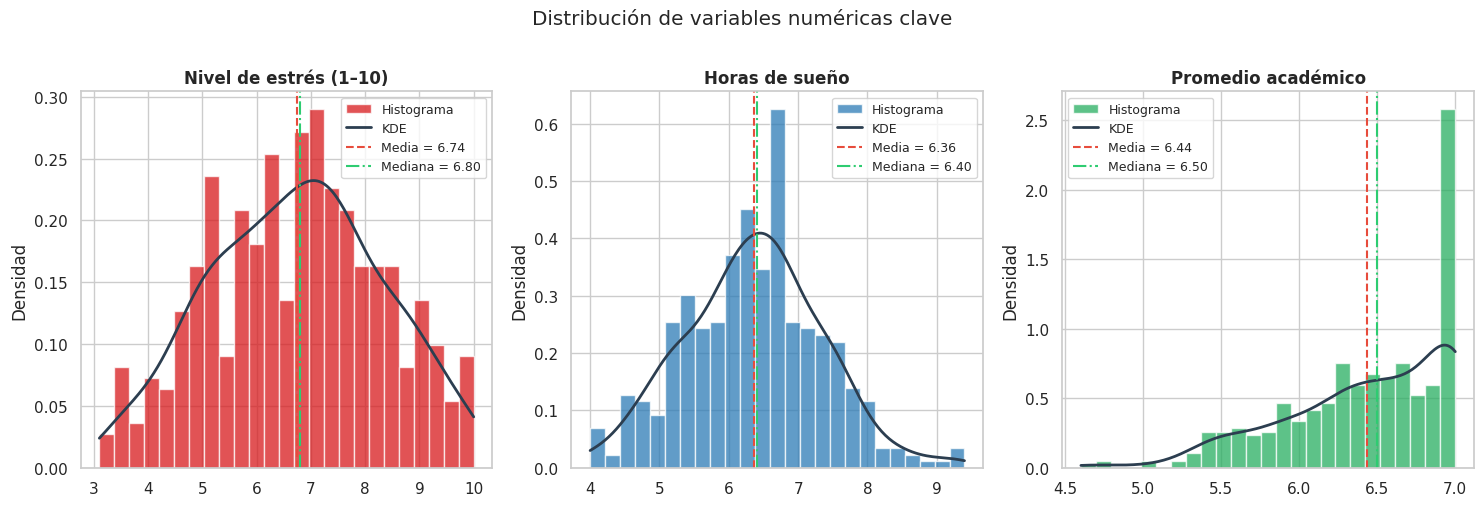

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Distribución de variables numéricas clave', y=1.01)

configs = [
    ('nivel_estres',   'Nivel de estrés (1–10)',   PAL_ACC),
    ('horas_sueno',    'Horas de sueño',            PAL_MAIN),
    ('promedio',       'Promedio académico',        '#27ae60'),
]

for ax, (col, titulo, color) in zip(axes, configs):
    media   = df[col].mean()
    mediana = df[col].median()

    ax.hist(df[col], bins=25, color=color, alpha=0.75,
            edgecolor='white', density=True, label='Histograma')

    # Curva de densidad (KDE)
    kde_x = np.linspace(df[col].min(), df[col].max(), 200)
    kde   = stats.gaussian_kde(df[col])
    ax.plot(kde_x, kde(kde_x), color='#2c3e50', linewidth=2, label='KDE')

    # Líneas de media y mediana
    ax.axvline(media,   color='#e74c3c', linestyle='--', linewidth=1.5,
               label=f'Media = {media:.2f}')
    ax.axvline(mediana, color='#2ecc71', linestyle='-.',  linewidth=1.5,
               label=f'Mediana = {mediana:.2f}')

    ax.set_title(titulo)
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### 3.2 Boxplots — comparando grupos

```
Anatomía de un boxplot:

   ─── límite superior (Q3 + 1.5×IQR)
   ─┬─ Q3 (percentil 75)
    │  IQR (caja)
   ─┴─ Q1 (percentil 25)
   ─── límite inferior (Q1 − 1.5×IQR)
    ○  outlier (fuera de los límites)
   ─── mediana (línea dentro de la caja)
```

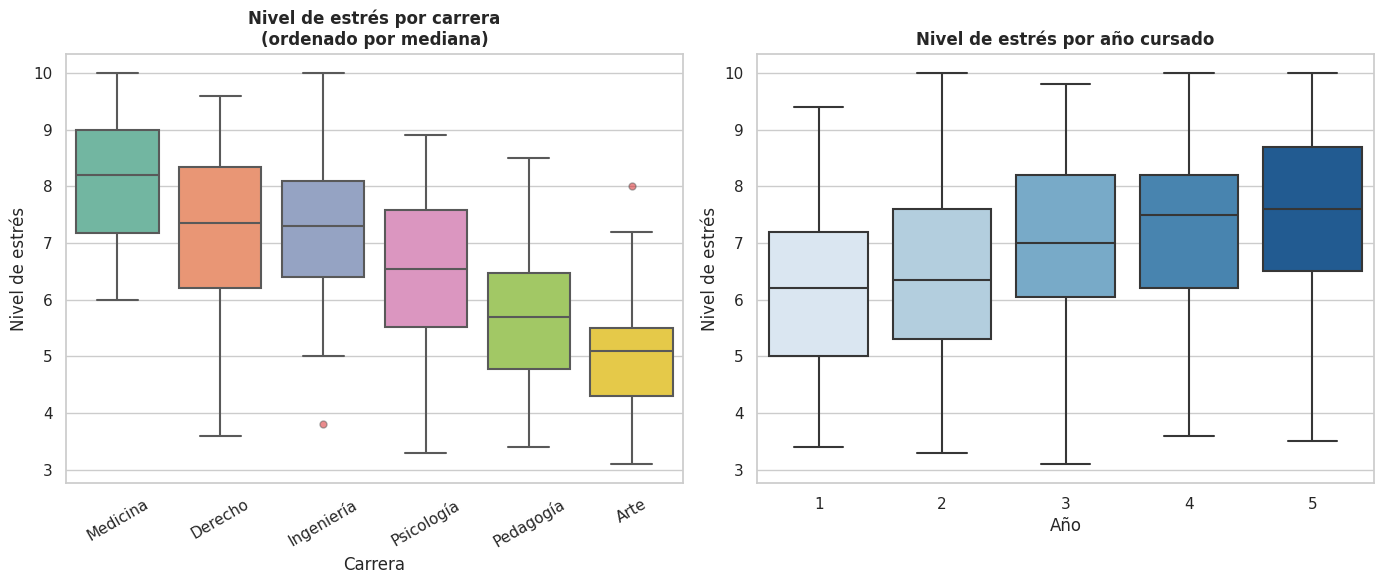

Observaciones:
  - Medicina y Derecho presentan las medianas de estrés más altas
  - El estrés tiende a aumentar con el año cursado
  - Arte tiene la distribución más baja y compacta


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot 1: estrés por carrera
orden_carrera = (df.groupby('carrera')['nivel_estres']
                   .median()
                   .sort_values(ascending=False)
                   .index)
sns.boxplot(
    data=df, x='carrera', y='nivel_estres', order=orden_carrera,
    palette='Set2', ax=axes[0], linewidth=1.5,
    flierprops=dict(marker='o', markerfacecolor=PAL_ACC, alpha=0.5, markersize=5)
)
axes[0].set_title('Nivel de estrés por carrera\n(ordenado por mediana)')
axes[0].set_xlabel('Carrera')
axes[0].set_ylabel('Nivel de estrés')
axes[0].tick_params(axis='x', rotation=30)

# Boxplot 2: estrés por año
sns.boxplot(
    data=df, x='ano', y='nivel_estres',
    palette='Blues', ax=axes[1], linewidth=1.5,
    flierprops=dict(marker='o', markerfacecolor=PAL_ACC, alpha=0.5, markersize=5)
)
axes[1].set_title('Nivel de estrés por año cursado')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Nivel de estrés')

plt.tight_layout()
plt.show()

print('Observaciones:')
print('  - Medicina y Derecho presentan las medianas de estrés más altas')
print('  - El estrés tiende a aumentar con el año cursado')
print('  - Arte tiene la distribución más baja y compacta')

### 3.3 Violinplots — distribución completa + comparación de grupos

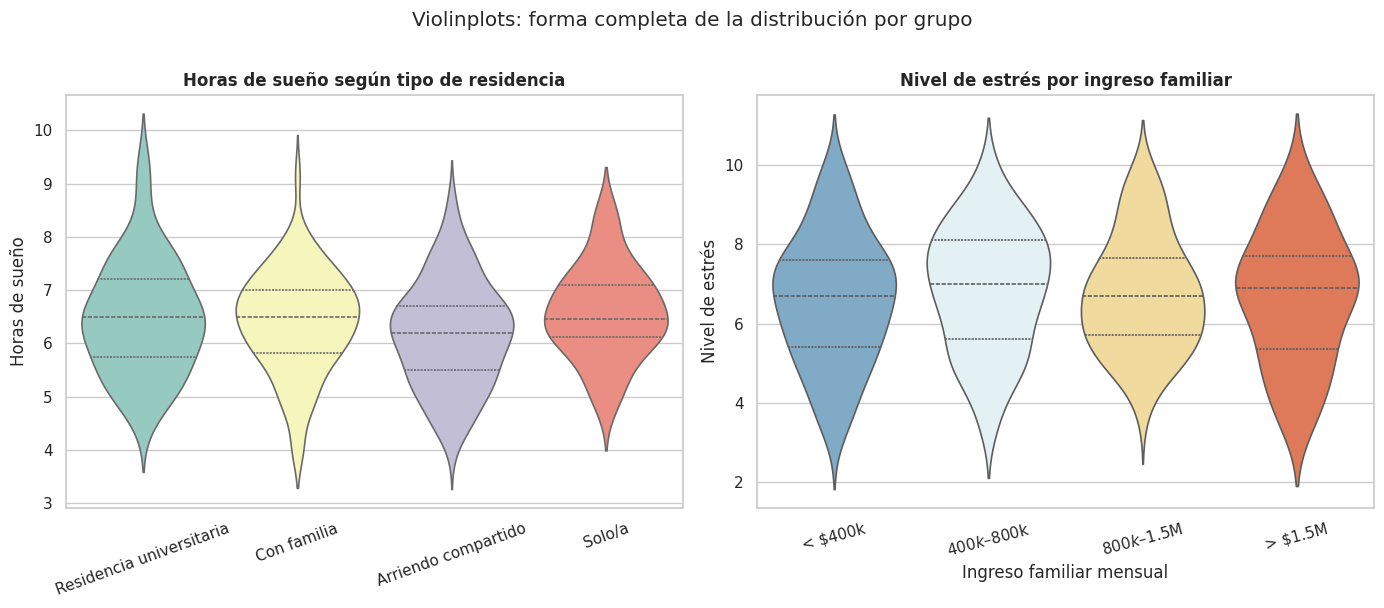

Ventaja del violinplot sobre el boxplot:
  → Muestra si la distribución es unimodal, bimodal o asimétrica
  → El boxplot solo muestra percentiles, no la forma completa


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Violinplot 1: horas de sueño por residencia
sns.violinplot(
    data=df, x='residencia', y='horas_sueno',
    palette='Set3', inner='quartile', ax=axes[0], linewidth=1.2
)
axes[0].set_title('Horas de sueño según tipo de residencia')
axes[0].set_xlabel('')
axes[0].set_ylabel('Horas de sueño')
axes[0].tick_params(axis='x', rotation=20)

# Violinplot 2: estrés por nivel de ingreso familiar
orden_ingreso = ['< $400k', '$400k–$800k', '$800k–$1.5M', '> $1.5M']
sns.violinplot(
    data=df, x='ingreso_fam', y='nivel_estres',
    order=orden_ingreso, palette='RdYlBu_r',
    inner='quartile', ax=axes[1], linewidth=1.2
)
axes[1].set_title('Nivel de estrés por ingreso familiar')
axes[1].set_xlabel('Ingreso familiar mensual')
axes[1].set_ylabel('Nivel de estrés')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Violinplots: forma completa de la distribución por grupo', y=1.01)
plt.tight_layout()
plt.show()

print('Ventaja del violinplot sobre el boxplot:')
print('  → Muestra si la distribución es unimodal, bimodal o asimétrica')
print('  → El boxplot solo muestra percentiles, no la forma completa')

### 3.4 Barplots y Countplots — variables categóricas

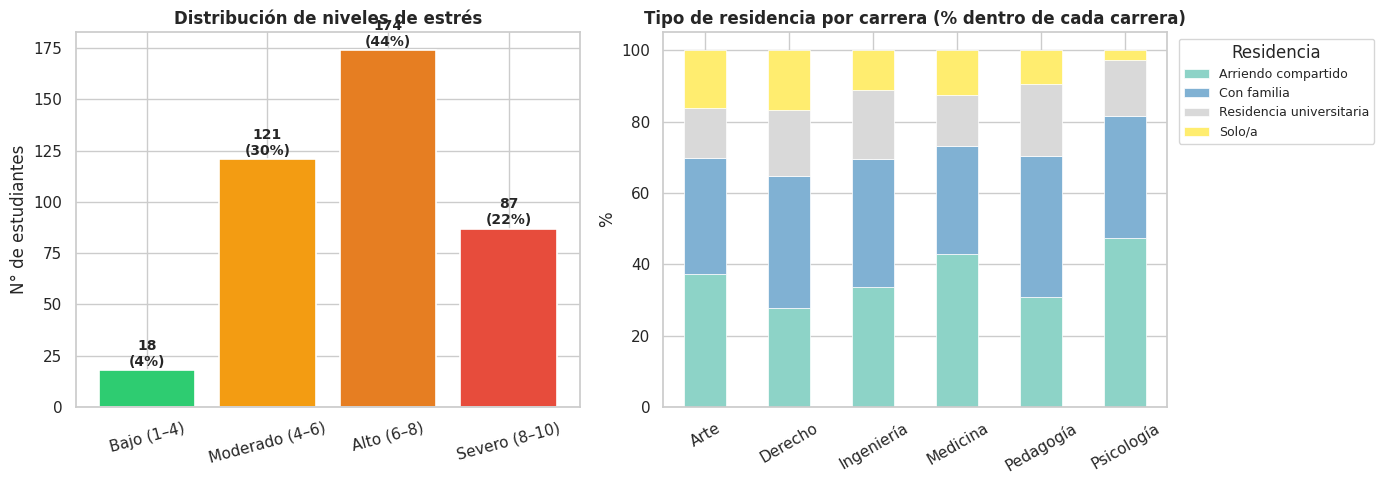

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Countplot: distribución de categoría de estrés
orden_cat = ['Bajo (1–4)', 'Moderado (4–6)', 'Alto (6–8)', 'Severo (8–10)']
conteo_cat = df['cat_estres'].value_counts().reindex(orden_cat)
colores_cat = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']

bars = axes[0].bar(conteo_cat.index, conteo_cat.values,
                    color=colores_cat, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, conteo_cat.values):
    pct = val / len(df) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 2,
                 f'{val}\n({pct:.0f}%)',
                 ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Distribución de niveles de estrés')
axes[0].set_ylabel('N° de estudiantes')
axes[0].tick_params(axis='x', rotation=15)

# Barplot apilado: residencia por carrera
tabla_res = pd.crosstab(df['carrera'], df['residencia'], normalize='index') * 100
tabla_res.plot(kind='bar', stacked=True, ax=axes[1],
               colormap='Set3', edgecolor='white', linewidth=0.5)
axes[1].set_title('Tipo de residencia por carrera (% dentro de cada carrera)')
axes[1].set_ylabel('%')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Residencia', bbox_to_anchor=(1.01, 1), fontsize=9)

plt.tight_layout()
plt.show()

---

## 🔗 Sección 4 — Relaciones entre Variables

```
¿Qué tipo de relación?                → ¿Qué gráfico usar?
──────────────────────────────────────────────────────────────────
Numérica vs Numérica                  → Scatter plot
Numérica vs Numérica (muchas vars)    → Pairplot / Heatmap correlación
Numérica vs Categórica                → Boxplot, violinplot, barplot de medias
Categórica vs Categórica              → Crosstab, heatmap de frecuencias
```

### 4.1 Scatter plots — relaciones numéricas

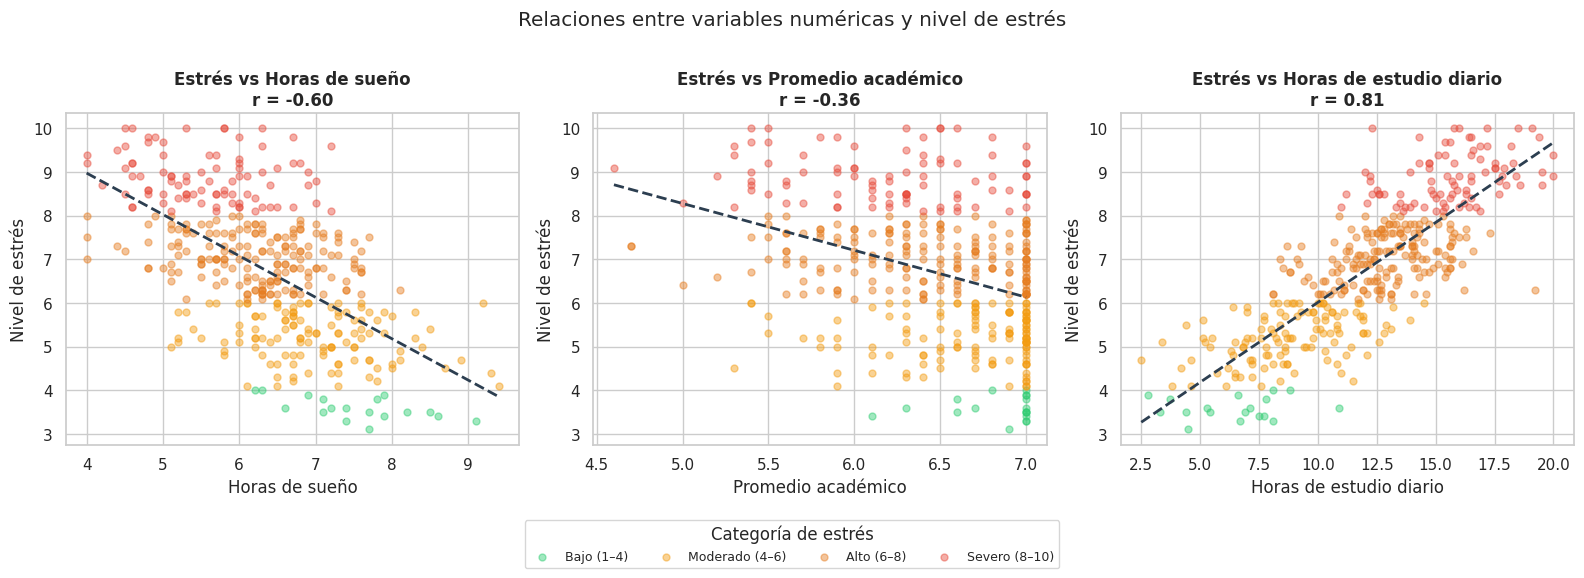

r = coeficiente de correlación de Pearson
  |r| > 0.7 → correlación fuerte
  |r| 0.3–0.7 → correlación moderada
  |r| < 0.3 → correlación débil


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Relaciones entre variables numéricas y nivel de estrés', y=1.01)

scatter_configs = [
    ('horas_sueno',    'Horas de sueño'),
    ('promedio',       'Promedio académico'),
    ('horas_estudio',  'Horas de estudio diario'),
]

for ax, (col, etiqueta) in zip(axes, scatter_configs):
    # Colorear por categoría de estrés
    for cat, color in zip(orden_cat, colores_cat):
        mask = df['cat_estres'] == cat
        ax.scatter(df.loc[mask, col], df.loc[mask, 'nivel_estres'],
                   c=color, alpha=0.45, s=25, label=cat)

    # Línea de regresión
    m, b, r, p, _ = stats.linregress(df[col], df['nivel_estres'])
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_line, m * x_line + b, color='#2c3e50',
            linewidth=2, linestyle='--')
    ax.set_title(f'Estrés vs {etiqueta}\nr = {r:.2f}')
    ax.set_xlabel(etiqueta)
    ax.set_ylabel('Nivel de estrés')

# Una sola leyenda para todos
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Categoría de estrés',
           loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.12), fontsize=9)

plt.tight_layout()
plt.show()

print('r = coeficiente de correlación de Pearson')
print('  |r| > 0.7 → correlación fuerte')
print('  |r| 0.3–0.7 → correlación moderada')
print('  |r| < 0.3 → correlación débil')

### 4.2 Heatmap de correlaciones

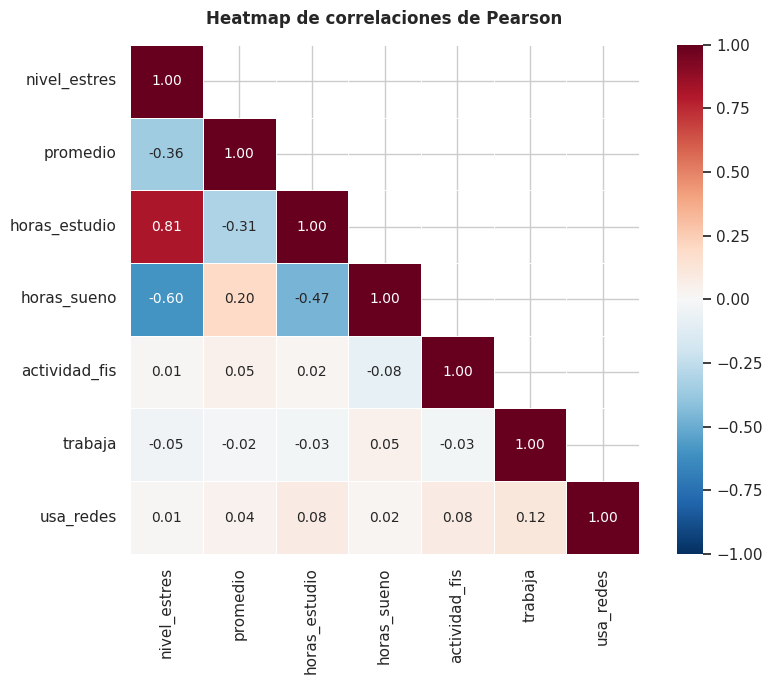

Correlaciones más fuertes con nivel_estres:
  horas_estudio        r = +0.81  ↑
  horas_sueno          r = -0.60  ↓
  promedio             r = -0.36  ↓
  trabaja              r = -0.05  ↓
  usa_redes            r = +0.01  ↑
  actividad_fis        r = +0.01  ↑


In [11]:
# Calcular la matriz de correlación
cols_corr = ['nivel_estres', 'promedio', 'horas_estudio',
             'horas_sueno', 'actividad_fis', 'trabaja', 'usa_redes']

corr_matrix = df[cols_corr].corr()

fig, ax = plt.subplots(figsize=(9, 7))

# Máscara para el triángulo superior (evita redundancia)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0,
    vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    square=True, ax=ax,
    annot_kws={'size': 10}
)

ax.set_title('Heatmap de correlaciones de Pearson', pad=15)
plt.tight_layout()
plt.show()

# Las 3 correlaciones más fuertes con nivel_estres
print('Correlaciones más fuertes con nivel_estres:')
corr_estres = corr_matrix['nivel_estres'].drop('nivel_estres').sort_values(key=abs, ascending=False)
for var, r in corr_estres.items():
    signo = '↑' if r > 0 else '↓'
    print(f'  {var:<20} r = {r:+.2f}  {signo}')

### 4.3 Pairplot — exploración masiva de relaciones

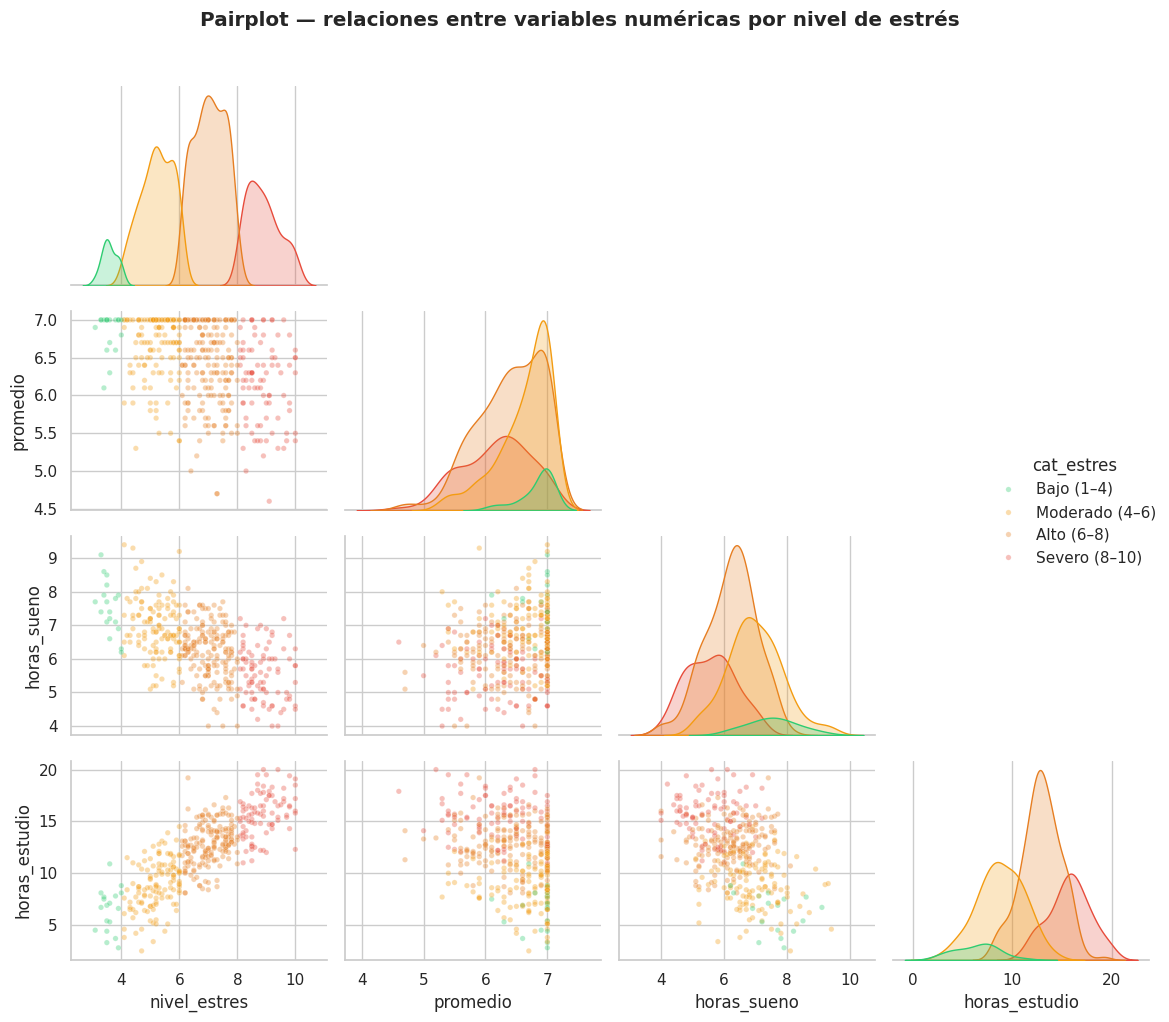

In [12]:
# Pairplot: histogramas en la diagonal, scatter en las celdas fuera de diagonal
# Coloreado por categoría de estrés

cols_pair = ['nivel_estres', 'promedio', 'horas_sueno', 'horas_estudio']

g = sns.pairplot(
    df[cols_pair + ['cat_estres']].dropna(),
    hue='cat_estres',
    hue_order=orden_cat,
    palette={'Bajo (1–4)': '#2ecc71', 'Moderado (4–6)': '#f39c12',
             'Alto (6–8)': '#e67e22', 'Severo (8–10)': '#e74c3c'},
    diag_kind='kde',
    plot_kws={'alpha': 0.35, 's': 15},
    corner=True   # solo triángulo inferior
)

g.figure.suptitle('Pairplot — relaciones entre variables numéricas por nivel de estrés',
                   y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.4 Crosstab — dos variables categóricas

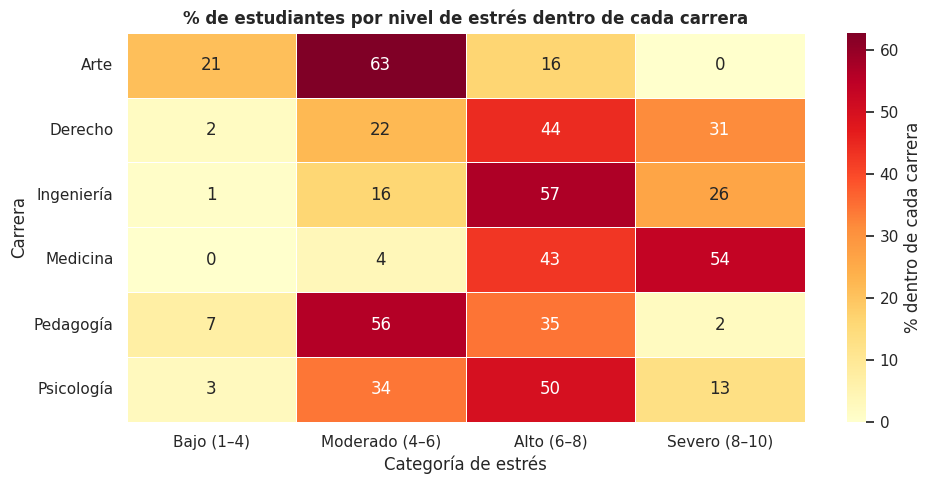

In [13]:
# Tabla de contingencia: carrera × categoría de estrés
ct = pd.crosstab(
    df['carrera'],
    df['cat_estres'],
    values=df['nivel_estres'],
    aggfunc='count',
    normalize='index'
) * 100

ct = ct[orden_cat]   # reordenar columnas

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    ct, annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.5, linecolor='white',
    ax=ax, cbar_kws={'label': '% dentro de cada carrera'}
)
ax.set_title('% de estudiantes por nivel de estrés dentro de cada carrera')
ax.set_xlabel('Categoría de estrés')
ax.set_ylabel('Carrera')
plt.tight_layout()
plt.show()

---

## ✨ Sección 5 — Gráficos Avanzados y Combinados

### 5.1 Barplot con intervalo de confianza

Seaborn calcula automáticamente el intervalo de confianza del 95% — mucho más honesto que solo mostrar la media.

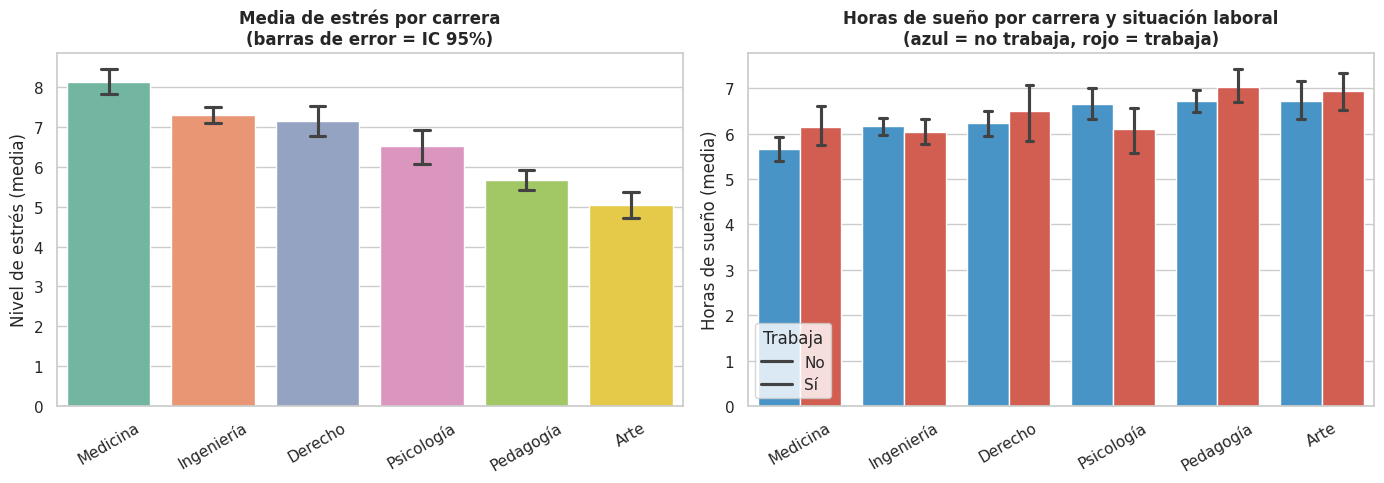

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Media de estrés por carrera (con IC 95%)
orden_media = (df.groupby('carrera')['nivel_estres']
                 .mean().sort_values(ascending=False).index)

sns.barplot(
    data=df, x='carrera', y='nivel_estres',
    order=orden_media, palette='Set2',
    errorbar='ci', capsize=0.15,
    ax=axes[0]
)
axes[0].set_title('Media de estrés por carrera\n(barras de error = IC 95%)')
axes[0].set_ylabel('Nivel de estrés (media)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

# Media de sueño por carrera Y si trabaja o no
sns.barplot(
    data=df, x='carrera', y='horas_sueno',
    hue='trabaja', palette=['#3498db', '#e74c3c'],
    errorbar='ci', capsize=0.15,
    order=orden_media, ax=axes[1]
)
axes[1].set_title('Horas de sueño por carrera y situación laboral\n(azul = no trabaja, rojo = trabaja)')
axes[1].set_ylabel('Horas de sueño (media)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Trabaja', labels=['No', 'Sí'])

plt.tight_layout()
plt.show()

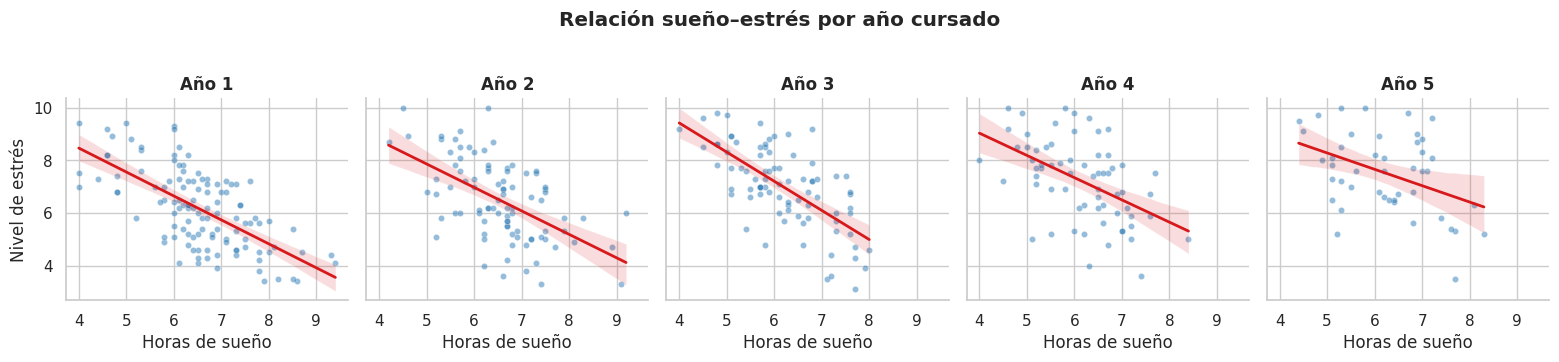

In [15]:
# FacetGrid: múltiples paneles automáticos por categoría
# Muestra la relación sueño-estrés separada por año cursado

g = sns.FacetGrid(df, col='ano', col_wrap=5,
                  height=3.5, aspect=0.9,
                  palette='Blues')
g.map_dataframe(sns.scatterplot, x='horas_sueno', y='nivel_estres',
                alpha=0.5, s=20, color=PAL_MAIN)
g.map_dataframe(sns.regplot, x='horas_sueno', y='nivel_estres',
                scatter=False, color=PAL_ACC, line_kws={'linewidth': 2})
g.set_titles('Año {col_name}')
g.set_axis_labels('Horas de sueño', 'Nivel de estrés')
g.figure.suptitle('Relación sueño–estrés por año cursado', y=1.03, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
# Gráfico interactivo con Plotly (opcional)
if PLOTLY:
    fig_px = px.scatter(
        df,
        x='horas_sueno',
        y='nivel_estres',
        color='carrera',
        size='horas_estudio',
        hover_data=['promedio', 'residencia', 'ingreso_fam'],
        title='Estrés vs Sueño (tamaño = horas de estudio) — interactivo',
        labels={
            'horas_sueno': 'Horas de sueño',
            'nivel_estres': 'Nivel de estrés',
            'carrera': 'Carrera'
        },
        opacity=0.7,
        template='simple_white'
    )
    fig_px.show()
else:
    print('Plotly no disponible. Instala con: !pip install plotly')

---

## 📝 Sección 5 — Cómo Comunicar los Hallazgos del EDA

Un EDA no termina cuando produces el último gráfico. Termina cuando puedes responder:

**¿Qué le dirías a alguien que nunca vio este dataset?**

### Estructura de un reporte exploratorio

```
1. CONTEXTO
   ¿De dónde vienen los datos? ¿Cuántos registros? ¿Qué período?

2. PREGUNTA
   ¿Qué querías responder? ¿Evolucionó la pregunta al ver los datos?

3. HALLAZGOS PRINCIPALES (máximo 5)
   Cada hallazgo = una oración + un gráfico que lo sustenta
   Empieza por el hallazgo más importante, no por el más fácil

4. LIMITACIONES
   ¿Qué no puedes concluir con estos datos? ¿Qué dato faltaría?

5. PRÓXIMOS PASOS
   ¿Qué modelo probarías? ¿Qué hipótesis queda pendiente?
```

### Ejemplo de hallazgo bien comunicado

| ❌ Hallazgo vago | ✅ Hallazgo preciso |
|---|---|
| "El sueño está relacionado con el estrés" | "Los estudiantes que duermen menos de 6 horas reportan en promedio 2.1 puntos más de estrés que quienes duermen 8+ horas (r = −0.58)" |
| "Medicina tiene mucho estrés" | "Medicina tiene la mediana más alta de estrés (7.8/10) y el 45% de sus estudiantes reporta nivel Severo, el doble que Pedagogía" |
| "El promedio y el estrés están relacionados" | "La relación entre promedio y estrés es no lineal: estrés moderado coexiste con los mejores promedios; estrés severo correlaciona con caída académica" |

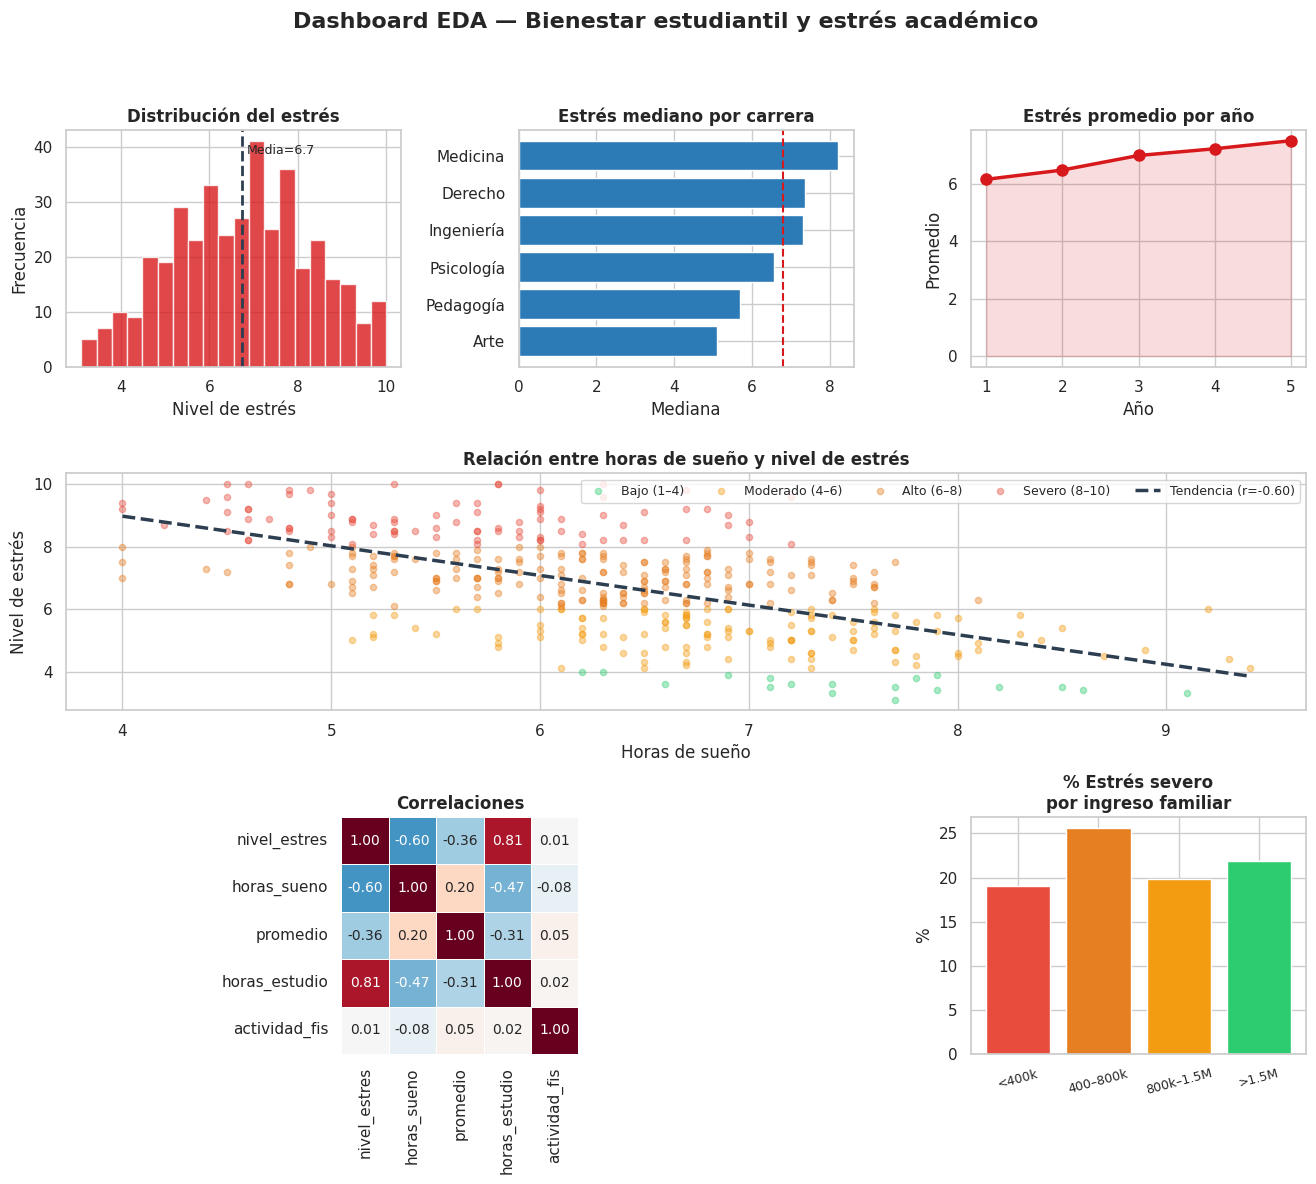

💾 Dashboard guardado como eda_dashboard.png


In [17]:
# Dashboard de hallazgos: un resumen visual de los principales resultados

fig = plt.figure(figsize=(16, 12))
fig.suptitle('Dashboard EDA — Bienestar estudiantil y estrés académico',
             fontsize=16, fontweight='bold', y=0.98)

gs = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

# Panel 1: Distribución de estrés
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df['nivel_estres'], bins=20, color=PAL_ACC, alpha=0.8, edgecolor='white')
ax1.axvline(df['nivel_estres'].mean(), color='#2c3e50', linestyle='--', linewidth=2)
ax1.set_title('Distribución del estrés')
ax1.set_xlabel('Nivel de estrés')
ax1.set_ylabel('Frecuencia')
ax1.text(df['nivel_estres'].mean() + 0.1, ax1.get_ylim()[1]*0.9,
         f'Media={df["nivel_estres"].mean():.1f}', fontsize=9)

# Panel 2: Mediana por carrera
ax2 = fig.add_subplot(gs[0, 1])
med_carrera = df.groupby('carrera')['nivel_estres'].median().sort_values()
ax2.barh(med_carrera.index, med_carrera.values, color=PAL_MAIN, edgecolor='white')
ax2.set_title('Estrés mediano por carrera')
ax2.set_xlabel('Mediana')
ax2.axvline(df['nivel_estres'].median(), color=PAL_ACC, linestyle='--', linewidth=1.5)

# Panel 3: Estrés por año
ax3 = fig.add_subplot(gs[0, 2])
med_ano = df.groupby('ano')['nivel_estres'].mean()
ax3.plot(med_ano.index, med_ano.values, marker='o', markersize=8,
          color=PAL_ACC, linewidth=2.5)
ax3.fill_between(med_ano.index, med_ano.values, alpha=0.15, color=PAL_ACC)
ax3.set_title('Estrés promedio por año')
ax3.set_xlabel('Año')
ax3.set_ylabel('Promedio')
ax3.set_xticks([1, 2, 3, 4, 5])

# Panel 4: Sueño vs Estrés (scatter)
ax4 = fig.add_subplot(gs[1, :])
for cat, color in zip(orden_cat, colores_cat):
    mask = df['cat_estres'] == cat
    ax4.scatter(df.loc[mask, 'horas_sueno'], df.loc[mask, 'nivel_estres'],
                c=color, alpha=0.4, s=20, label=cat)
m, b, r, *_ = stats.linregress(df['horas_sueno'], df['nivel_estres'])
x_l = np.linspace(df['horas_sueno'].min(), df['horas_sueno'].max(), 100)
ax4.plot(x_l, m * x_l + b, color='#2c3e50', linewidth=2.5, linestyle='--',
         label=f'Tendencia (r={r:.2f})')
ax4.set_title('Relación entre horas de sueño y nivel de estrés')
ax4.set_xlabel('Horas de sueño')
ax4.set_ylabel('Nivel de estrés')
ax4.legend(ncol=5, fontsize=9, loc='upper right')

# Panel 5: Heatmap de correlaciones (simplificado)
ax5 = fig.add_subplot(gs[2, 0:2])
corr_simp = df[['nivel_estres','horas_sueno','promedio','horas_estudio','actividad_fis']].corr()
sns.heatmap(corr_simp, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax5, cbar=False, square=True, annot_kws={'size': 10})
ax5.set_title('Correlaciones')

# Panel 6: % Estrés severo por ingreso
ax6 = fig.add_subplot(gs[2, 2])
pct_severo = (df[df['cat_estres']=='Severo (8–10)']
              .groupby('ingreso_fam').size()
              / df.groupby('ingreso_fam').size() * 100).reindex(orden_ingreso)
ax6.bar(range(len(orden_ingreso)), pct_severo.values,
         color=['#e74c3c','#e67e22','#f39c12','#2ecc71'], edgecolor='white')
ax6.set_xticks(range(len(orden_ingreso)))
ax6.set_xticklabels(['<400k', '400–800k', '800k–1.5M', '>1.5M'], rotation=15, fontsize=9)
ax6.set_title('% Estrés severo\npor ingreso familiar')
ax6.set_ylabel('%')

plt.savefig('eda_dashboard.png', dpi=130, bbox_inches='tight')
plt.show()
print('💾 Dashboard guardado como eda_dashboard.png')

---

## 🛠️ Sección 6 — Construye tu Propio EDA

Carga tu dataset limpio de la Clase 3 y construye un notebook de EDA completo siguiendo la estructura de abajo. Cada celda de código tiene instrucciones de qué adaptar.

In [ ]:
from google.colab import files

uploaded = files.upload()
nombre = list(uploaded.keys())[0]

if nombre.endswith('.csv'):
    df_mio = pd.read_csv(nombre)
elif nombre.endswith(('.xlsx', '.xls')):
    df_mio = pd.read_excel(nombre)
elif nombre.endswith('.parquet'):
    df_mio = pd.read_parquet(nombre)

print(f'✅ Dataset cargado: {df_mio.shape[0]} filas × {df_mio.shape[1]} columnas')
df_mio.head()

### 🧭 1. Contexto y pregunta

✏️ **Completa aquí:**

- **Dataset:** *nombre y fuente*
- **¿Qué representa cada fila?** *una persona / una venta / un día / ...*
- **Período:** *fechas que cubre (si aplica)*
- **Pregunta de investigación:** *¿qué quieres responder?*
- **Variable objetivo (Y):** *la variable que quieres predecir o explicar*
- **Variables explicativas (X):** *columnas que usarás para responder la pregunta*

In [ ]:
# Vista rápida del dataset
print(f'Dimensiones: {df_mio.shape}')
print()
print('Tipos de datos:')
print(df_mio.dtypes)
print()
df_mio.describe()

### 📊 2. Distribución de la variable objetivo

In [ ]:
# ── ADAPTA: reemplaza 'mi_variable_objetivo' con el nombre de tu variable Y
variable_y = 'mi_variable_objetivo'

if df_mio[variable_y].dtype in ['float64', 'int64']:
    # Variable numérica
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].hist(df_mio[variable_y].dropna(), bins=25,
                 color=PAL_MAIN, edgecolor='white', alpha=0.8)
    axes[0].axvline(df_mio[variable_y].mean(), color=PAL_ACC,
                    linestyle='--', label=f'Media = {df_mio[variable_y].mean():.2f}')
    axes[0].axvline(df_mio[variable_y].median(), color='#27ae60',
                    linestyle='-.', label=f'Mediana = {df_mio[variable_y].median():.2f}')
    axes[0].set_title(f'Distribución de {variable_y}')
    axes[0].legend()

    axes[1].boxplot(df_mio[variable_y].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#d6eaf8'),
                    medianprops=dict(color='#2c3e50', linewidth=2),
                    flierprops=dict(marker='o', color=PAL_ACC, markersize=6))
    axes[1].set_title(f'Boxplot de {variable_y}')
    axes[1].set_xticks([])

    plt.tight_layout()
    plt.show()

else:
    # Variable categórica
    conteo = df_mio[variable_y].value_counts()
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(conteo.index.astype(str), conteo.values, color=PAL_CAT[:len(conteo)])
    ax.set_title(f'Frecuencia de {variable_y}')
    ax.set_ylabel('N°')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

✏️ **Hallazgo 1:**  
*Describe la distribución de tu variable objetivo. ¿Es simétrica? ¿Sesgada? ¿Hay valores extremos? ¿Qué te sorprendió?*

### 📊 3. Distribución de las variables explicativas

In [ ]:
# Histogramas de todas las variables numéricas
cols_num_mio = df_mio.select_dtypes(include='number').columns.tolist()

if variable_y in cols_num_mio:
    cols_num_mio = [c for c in cols_num_mio if c != variable_y]

n_c = len(cols_num_mio)
if n_c > 0:
    n_filas = (n_c + 2) // 3
    fig, axes = plt.subplots(n_filas, 3, figsize=(14, 4 * n_filas))
    axes = np.array(axes).flatten()

    for i, col in enumerate(cols_num_mio[:9]):
        axes[i].hist(df_mio[col].dropna(), bins=25, color=PAL_CAT[i % len(PAL_CAT)],
                     edgecolor='white', alpha=0.85)
        axes[i].set_title(col, fontweight='bold', fontsize=10)
        axes[i].set_ylabel('Frecuencia')

    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Distribución de variables numéricas', fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print('No hay variables numéricas adicionales.')

In [ ]:
# Barplots de variables categóricas
cols_cat_mio = df_mio.select_dtypes('object').columns.tolist()

if variable_y in cols_cat_mio:
    cols_cat_mio = [c for c in cols_cat_mio if c != variable_y]

n_c = len(cols_cat_mio)
if n_c > 0:
    n_filas = (n_c + 1) // 2
    fig, axes = plt.subplots(n_filas, 2, figsize=(14, 4 * n_filas))
    axes = np.array(axes).flatten()

    for i, col in enumerate(cols_cat_mio[:8]):
        conteo = df_mio[col].value_counts().head(12)
        axes[i].barh(conteo.index.astype(str), conteo.values,
                      color=PAL_CAT[i % len(PAL_CAT)], edgecolor='white')
        axes[i].set_title(col, fontweight='bold', fontsize=10)
        axes[i].set_xlabel('Frecuencia')

    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Distribución de variables categóricas', fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print('No hay variables categóricas adicionales.')

✏️ **Hallazgo 2:**  
*¿Hay alguna variable con distribución inesperada? ¿Categorías muy desbalanceadas? ¿Variables con poca variabilidad (casi constantes)?*

### 🔗 4. Relaciones con la variable objetivo

In [ ]:
# Heatmap de correlaciones
cols_corr_mio = df_mio.select_dtypes(include='number').columns.tolist()

if len(cols_corr_mio) >= 2:
    corr_mia = df_mio[cols_corr_mio].corr()
    mask = np.triu(np.ones_like(corr_mia, dtype=bool), k=1)

    fig, ax = plt.subplots(figsize=(max(8, len(cols_corr_mio)), max(6, len(cols_corr_mio)-1)))
    sns.heatmap(corr_mia, mask=mask, annot=True, fmt='.2f',
                cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                linewidths=0.5, linecolor='white', square=True, ax=ax)
    ax.set_title('Heatmap de correlaciones', pad=12)
    plt.tight_layout()
    plt.show()

    if variable_y in cols_corr_mio:
        print(f'\nCorrelaciones con {variable_y} (ordenadas):')
        corr_target = corr_mia[variable_y].drop(variable_y).sort_values(key=abs, ascending=False)
        for var, r in corr_target.items():
            print(f'  {var:<30} r = {r:+.3f}')
else:
    print('Se necesitan al menos 2 variables numéricas para el heatmap.')

In [ ]:
# Scatter plots: variable Y vs cada variable numérica X
# ── ADAPTA: si tu Y es categórica, usa boxplots en lugar de scatter

cols_x_num = [c for c in cols_corr_mio if c != variable_y]

if df_mio[variable_y].dtype in ['float64', 'int64'] and len(cols_x_num) > 0:
    n_plot = min(len(cols_x_num), 6)
    n_filas = (n_plot + 1) // 2
    fig, axes = plt.subplots(n_filas, 2, figsize=(14, 5 * n_filas))
    axes = np.array(axes).flatten()

    for i, col in enumerate(cols_x_num[:n_plot]):
        axes[i].scatter(df_mio[col], df_mio[variable_y],
                         alpha=0.4, s=20, color=PAL_CAT[i % len(PAL_CAT)])
        # Línea de tendencia
        datos_ok = df_mio[[col, variable_y]].dropna()
        if len(datos_ok) > 2:
            m, b, r, *_ = stats.linregress(datos_ok[col], datos_ok[variable_y])
            x_l = np.linspace(datos_ok[col].min(), datos_ok[col].max(), 100)
            axes[i].plot(x_l, m*x_l+b, color='#2c3e50', linewidth=2, linestyle='--')
            axes[i].set_title(f'{variable_y} vs {col}  (r={r:.2f})', fontsize=10)
        else:
            axes[i].set_title(f'{variable_y} vs {col}', fontsize=10)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel(variable_y)

    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(f'Relaciones con {variable_y}', fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print('Variable Y no numérica o sin variables X numéricas — usa boxplots.')

In [ ]:
# Boxplots: Y por cada variable categórica
cols_cat_x = [c for c in cols_cat_mio if c != variable_y]

if len(cols_cat_x) > 0 and df_mio[variable_y].dtype in ['float64', 'int64']:
    n_plot = min(len(cols_cat_x), 4)
    fig, axes = plt.subplots(1, n_plot, figsize=(5 * n_plot, 5))
    if n_plot == 1:
        axes = [axes]

    for i, col in enumerate(cols_cat_x[:n_plot]):
        orden = (df_mio.groupby(col)[variable_y]
                       .median().sort_values(ascending=False).index)
        sns.boxplot(data=df_mio, x=col, y=variable_y,
                    order=orden, palette='Set2',
                    ax=axes[i], linewidth=1.2,
                    flierprops=dict(marker='o', color=PAL_ACC, alpha=0.5, markersize=5))
        axes[i].set_title(f'{variable_y}\npor {col}', fontsize=10)
        axes[i].tick_params(axis='x', rotation=30)

    plt.suptitle(f'Distribución de {variable_y} por grupos', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('Sin variables categóricas X o variable Y no numérica.')

✏️ **Hallazgo 3:**  
*¿Qué variables tienen la correlación más fuerte con tu Y? ¿Hay alguna relación que te sorprendió? ¿Hay alguna que esperabas y no apareció?*

### 🔍 5. Exploración libre — tu hallazgo más interesante

Usa esta sección para profundizar en la relación o patrón que más te llamó la atención. Puedes hacer cualquier tipo de gráfico.

In [ ]:
# Espacio libre para tu exploración
# Sugerencias:
#   - Filtra un subgrupo específico y compáralo con el total
#   - Crea una variable nueva y grafica su relación con Y
#   - Haz un scatter coloreado por una tercera variable
#   - Calcula estadísticas por cruce de dos variables categóricas

print('Escribe aquí tu exploración libre 👇')

✏️ **Hallazgo 4 (el más interesante):**  
*Describe en 2-3 oraciones lo que encontraste y por qué crees que es relevante para tu pregunta de investigación.*

### ⚠️ 6. Limitaciones y próximos pasos

✏️ **Completa aquí:**

**Limitaciones del dataset:**
- *¿Qué variable importante falta?*
- *¿Hay sesgo en la muestra?*
- *¿Los datos son recientes o pueden estar desactualizados?*

**¿La pregunta de investigación sigue siendo respondible?**
- *Sí / No / Debe ajustarse — ¿cómo?*

**Próximos pasos:**
- *¿Qué modelo probarías primero?*
- *¿Qué hipótesis quieres probar con ese modelo?*

---

## 🎤 Sección 7 — Hito 1: Presentación Grupal

### Formato de la presentación (5 minutos por alumna)

```
ESTRUCTURA DE 5 MINUTOS
────────────────────────────────────────────────────────
  min 0–1   → Mi dataset: de dónde viene, qué representa
  min 1–2   → Mi pregunta de investigación y por qué me interesa
  min 2–4   → Mis 3 hallazgos clave del EDA (un gráfico por hallazgo)
  min 4–5   → Limitaciones que encontré y qué haré en las próximas clases
────────────────────────────────────────────────────────
```

### Tips para una presentación efectiva

- **Un gráfico = una idea.** No pongas dos gráficos distintos en la misma diapositiva.
- **El título del gráfico debe ser la conclusión**, no la descripción. En vez de *"Distribución de edades"*, pon *"Los usuarios mayores de 50 años abandonan el carrito 3× más"*.
- **No te disculpes** por los datos imperfectos — todo dataset real tiene limitaciones. Nómbralas con confianza.
- **Habla de las sorpresas.** Lo que no esperabas es más interesante que lo que confirmó tu hipótesis.

---

### Ficha de retroalimentación estructurada

Cada presentación recibe retroalimentación de la tutora y del grupo usando este formato:

In [ ]:
# Completa esta celda para cada presentación que veas
# Guárdala y úsala como referencia para tu propio proyecto

alumna_presentando   = "Nombre de quien presenta"
dataset_que_usa      = "Nombre del dataset"
pregunta_investigacion = "Escribe la pregunta de investigación que presentó"

# Retroalimentación (formato: 2 positivos + 1 sugerencia)
positivo_1    = "¿Qué hizo muy bien? (claridad del hallazgo, visualización, narrativa...)"
positivo_2    = "Otro aspecto positivo"
sugerencia    = "Una sola sugerencia concreta de mejora"

print('='*65)
print(f'  RETROALIMENTACIÓN — {alumna_presentando}')
print('='*65)
print(f'  Dataset:  {dataset_que_usa}')
print(f'  Pregunta: {pregunta_investigacion}')
print()
print(f'  ✅ {positivo_1}')
print(f'  ✅ {positivo_2}')
print(f'  💡 {sugerencia}')
print('='*65)

### Autoevaluación después de presentar

In [ ]:
# Rellena esto después de tu propia presentación

mi_nombre                = "Tu nombre"
lo_que_sali_bien         = "¿Qué funcionó en tu presentación?"
lo_que_cambiaria         = "¿Qué harías diferente?"
feedback_que_recibi      = "¿Cuál fue la sugerencia más útil que te dieron?"
ajuste_al_proyecto       = "¿Vas a cambiar algo en tu pregunta o enfoque después del feedback?"

print('='*65)
print(f'  AUTOEVALUACIÓN — {mi_nombre}')
print('='*65)
print(f'  Bien:     {lo_que_sali_bien}')
print(f'  Mejorar:  {lo_que_cambiaria}')
print(f'  Feedback: {feedback_que_recibi}')
print(f'  Ajuste:   {ajuste_al_proyecto}')
print('='*65)

---

## ✅ Resumen de la Clase 4

| Tema | Lo esencial |
|---|---|
| **Propósito del EDA** | Entender antes de modelar. Cada gráfico responde una pregunta específica |
| **Estadística descriptiva** | Media vs mediana: usa mediana cuando hay outliers o distribución sesgada |
| **Distribuciones** | Histograma + KDE para ver forma. Boxplot para comparar grupos. Violinplot para ver la forma completa |
| **Relaciones** | Scatter + línea de regresión para numéricas. Heatmap para ver todas a la vez. Boxplot para numérica vs categórica |
| **Correlación** | Solo mide relación **lineal**. `r` fuerte no implica causalidad. Siempre grafica antes de confiar en `r` |
| **Comunicar** | Cada hallazgo = una oración + un gráfico. El título del gráfico es la conclusión, no la descripción |
| **Hito 1** | Dataset → pregunta → 3 hallazgos → limitaciones. 5 minutos. Retroalimentación: 2 positivos + 1 sugerencia |

---

**Próxima sesión — Clase 5:** Modelos de Machine Learning supervisado. Con el EDA hecho y la pregunta validada, vamos a entrenar los primeros modelos.

**Tarea:** Incorpora el feedback que recibiste hoy a tu notebook de EDA. Si necesitas ajustar tu pregunta de investigación, hazlo ahora — es el último momento antes de empezar a modelar.

---
*Notebook elaborado para el curso Introducción a la Ciencia de Datos · Sesión 4*